In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***4.Machine Learning***

In [39]:
#Load the dataset
df = pd.read_csv('/content/bank_cleaned.csv')

In [46]:
#Separate X and Y

x = df.drop('y',axis=1)
y = df['y']

In [47]:
#Identify Categorical Columns
categorical_cols = x.select_dtypes(
    include='object'
).columns

numeric_cols = x.select_dtypes(
    exclude='object'
).columns

In [48]:
#Train-Test Split

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
#Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder


In [50]:
#Preprocessing:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_cols
        )
    ]
)

In [67]:
#Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('classifier',LogisticRegression(
            max_iter=1000
        ))
    ]
)

In [73]:
model1 = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('classifier',DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

In [74]:
model2 = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('classifier',RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

In [52]:
#Train Logistic Regression:
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [75]:
#Train Decision Tree
model1.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [77]:
#Train Random Forest:
model2.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [53]:
#Predict Logistic Reggression:
y_pred = model.predict(x_test)

In [79]:
#Predict Decision Tree
y_pred1 = model1.predict(x_test)

In [81]:
#Predict Random Forest
y_pred2 = model2.predict(x_test)

In [82]:
#Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [137]:
#Calculate

accuracy = accuracy_score(y_test,y_pred)*100

precision = precision_score(y_test,y_pred)*100

recall = recall_score(y_test,y_pred)*100

f1 = f1_score(y_test,y_pred)*100

print(f'Accuracy : {accuracy}')
print(f'Precision : {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(classification_report(y_test, y_pred))

Accuracy : 90.12495853146079
Precision : 64.44833625218914
Recall: 34.78260869565217
F1 Score: 45.18109269490485
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7985
           1       0.64      0.35      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



In [138]:
#Calculate

accuracy1 = accuracy_score(y_test,y_pred1)*100

precision1 = precision_score(y_test,y_pred1)*100

recall1 = recall_score(y_test,y_pred1)*100

f11 = f1_score(y_test,y_pred1)*100

print(f'Accuracy : {accuracy1}')
print(f'Precision : {precision1}')
print(f'Recall: {recall1}')
print(f'F1 Score: {f11}')
print(classification_report(y_test, y_pred1))

Accuracy : 87.45991374543846
Precision : 46.48798521256931
Recall: 47.54253308128544
F1 Score: 47.00934579439252
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.46      0.48      0.47      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.70      0.70      9043
weighted avg       0.88      0.87      0.88      9043



In [139]:
#Calculate

accuracy2 = accuracy_score(y_test,y_pred2)*100

precision2 = precision_score(y_test,y_pred2)*100

recall2 = recall_score(y_test,y_pred2)*100

f12 = f1_score(y_test,y_pred2)*100

print(f'Accuracy : {accuracy2}')
print(f'Precision : {precision2}')
print(f'Recall: {recall2}')
print(f'F1 Score: {f12}')
print(classification_report(y_test, y_pred2))

Accuracy : 90.69998894172288
Precision : 66.6156202143951
Recall: 41.11531190926276
F1 Score: 50.847457627118644
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.67      0.41      0.51      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.69      0.73      9043
weighted avg       0.90      0.91      0.90      9043



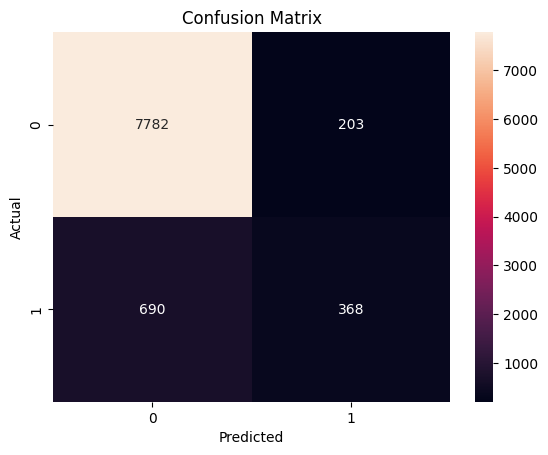

In [65]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

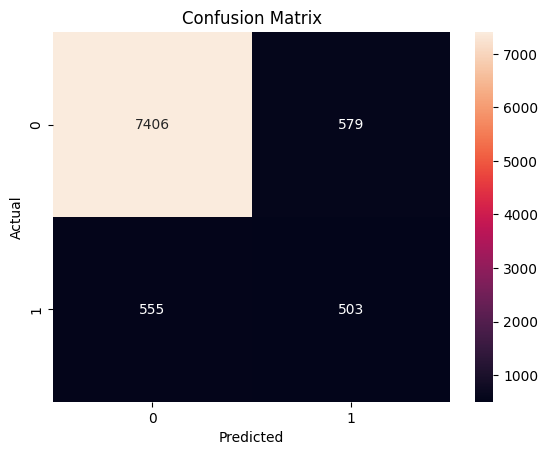

In [114]:
cm1 = confusion_matrix(
    y_test,
    y_pred1
)

sns.heatmap(
    cm1,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

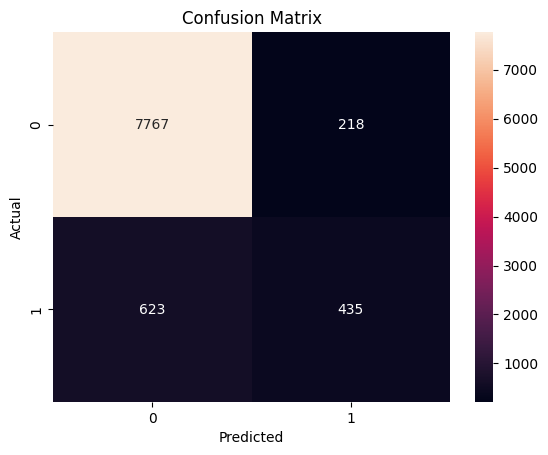

In [115]:
cm2 = confusion_matrix(
    y_test,
    y_pred2
)

sns.heatmap(
    cm2,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [175]:
print("Model                   Accuracy   Precision    Recall    F1 ")
print("________________________________________________________________________")
print(f"Logistic Regression :    {accuracy:.2f}       {precision:.2f}       {recall:.2f}   {f1:.2f}")
print("________________________________________________________________________")
print(f"Decision Tree :          {accuracy1:.2f}       {precision1:.2f}       {recall1:.2f}   {f11:.2f}")
print("________________________________________________________________________")
print(f"Random Forest :          {accuracy2:.2f}       {precision2:.2f}       {recall2:.2f}   {f12:.2f}")

Model                   Accuracy   Precision    Recall    F1 
________________________________________________________________________
Logistic Regression :    90.12       64.45       34.78   45.18
________________________________________________________________________
Decision Tree :          87.46       46.49       47.54   47.01
________________________________________________________________________
Random Forest :          90.70       66.62       41.12   50.85
